# 06 — West Java SBS Horticulture (Chili) Productivity (DS06)
**TaniAdapt Project — Regional Horticulture Outcome Target**
**Fase:** Phase 3 (Discovery & Acquisition) + Phase 4 (Dataset Quality Audit)

- **Sumber Resmi:** Dinas Tanaman Pangan dan Hortikultura Jawa Barat / Galura Data Jabar
- **Fokus Komoditas Hortikultura:** Cabai Besar dan Cabai Rawit (2017–2024)
- **AUDIT KRITIS TARGET OUTCOME:** Dataset ini berisi angka produktivitas statistik hasil panen agregat, BUKAN data insidensi atau label penyakit tanaman (disease incidence).


In [1]:
from pathlib import Path
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name.lower() == "notebook" else CWD
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "DS06_west_java_horticulture"
FIGURES_DIR = PROJECT_ROOT / "reports" / "dataset_audit" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Raw Data Dir:", RAW_DIR)


Project Root: C:\CODING\research_taniAdapt
Raw Data Dir: C:\CODING\research_taniAdapt\data\raw\DS06_west_java_horticulture


## Phase 3 & 4 — Audit Komoditas Cabai Besar & Cabai Rawit (2017–2024)
Membaca file statistik produktivitas Sayuran Buah Semusim (SBS) Jawa Barat.


In [2]:
df_sbs = pd.read_csv(RAW_DIR / "produktivitas_sbs_jabar.csv")
cabai_besar = df_sbs[df_sbs['komoditi'] == 'CABAI BESAR'].sort_values('tahun')
cabai_rawit = df_sbs[df_sbs['komoditi'] == 'CABAI RAWIT'].sort_values('tahun')

print("Observasi Cabai Besar:", len(cabai_besar), "| Tahun:", cabai_besar['tahun'].min(), "s.d.", cabai_besar['tahun'].max())
print("Observasi Cabai Rawit:", len(cabai_rawit), "| Tahun:", cabai_rawit['tahun'].min(), "s.d.", cabai_rawit['tahun'].max())
print("Satuan Resmi:", cabai_besar['satuan'].iloc[0])


Observasi Cabai Besar: 8 | Tahun: 2017 s.d. 2024
Observasi Cabai Rawit: 8 | Tahun: 2017 s.d. 2024
Satuan Resmi: KUINTAL PER HEKTAR


## Audit Kritis Validitas Target Outcome & Gap Analysis Variabel
Pemeriksaan ketat apakah dataset ini dapat digunakan untuk melatih model deteksi penyakit tanaman.


In [3]:
gap_analysis = pd.DataFrame([
    {"Variabel Agronomi": "Produktivitas Hasil Panen (Kuintal/Ha)", "Status Ketersediaan": "TERSEDIA (8 Tahun)", "Keterangan": "Target luaran hasil panen valid"},
    {"Variabel Agronomi": "Volume Produksi (Kuintal / Ton)", "Status Ketersediaan": "TERSEDIA (8 Tahun)", "Keterangan": "Tercatat di dataset produksi sayuran"},
    {"Variabel Agronomi": "Luas Panen / Tanam (Ha)", "Status Ketersediaan": "TERSEDIA (8 Tahun)", "Keterangan": "Bisa diturunkan dari produksi / produktivitas"},
    {"Variabel Agronomi": "Insidensi / Label Penyakit (OPT)", "Status Ketersediaan": "TIDAK TERSEDIA (ABSEN)", "Keterangan": "TIDAK BISA untuk supervised ML penyakit"},
    {"Variabel Agronomi": "Varietas Spesifik Benih Cabai", "Status Ketersediaan": "TIDAK TERSEDIA (ABSEN)", "Keterangan": "Hanya agregat nama komoditi umum"}
])

print("\n" + "="*60)
print("HASIL AUDIT TARGET OUTCOME (YIELD vs DISEASE):")
print("="*60)
print("1. Apakah dataset ini berisi angka hasil panen (Yield)? -> YA (VALID)")
print("2. Apakah dataset ini berisi label penyakit tanaman?     -> TIDAK (ABSEN)")
print("KESIMPULAN: Jangan latih ML klasifikasi penyakit dari dataset ini!")
print("="*60 + "\n")
display(gap_analysis)



HASIL AUDIT TARGET OUTCOME (YIELD vs DISEASE):
1. Apakah dataset ini berisi angka hasil panen (Yield)? -> YA (VALID)
2. Apakah dataset ini berisi label penyakit tanaman?     -> TIDAK (ABSEN)
KESIMPULAN: Jangan latih ML klasifikasi penyakit dari dataset ini!



,Variabel Agronomi,Status Ketersediaan,Keterangan
0,Produktivitas Hasil Panen (Kuintal/Ha),TERSEDIA (8 Tahun),Target luaran hasil panen valid
1,Volume Produksi (Kuintal / Ton),TERSEDIA (8 Tahun),Tercatat di dataset produksi sayuran
2,Luas Panen / Tanam (Ha),TERSEDIA (8 Tahun),Bisa diturunkan dari produksi / produktivitas
3,Insidensi / Label Penyakit (OPT),TIDAK TERSEDIA (ABSEN),TIDAK BISA untuk supervised ML penyakit
4,Varietas Spesifik Benih Cabai,TIDAK TERSEDIA (ABSEN),Hanya agregat nama komoditi umum


## Visualisasi Diagnostik Multi-Panel (Tren Produktivitas Cabai Rawit vs Cabai Besar)
Membandingkan dinamika produktivitas dua komoditas cabai utama di Jawa Barat (2017–2024).


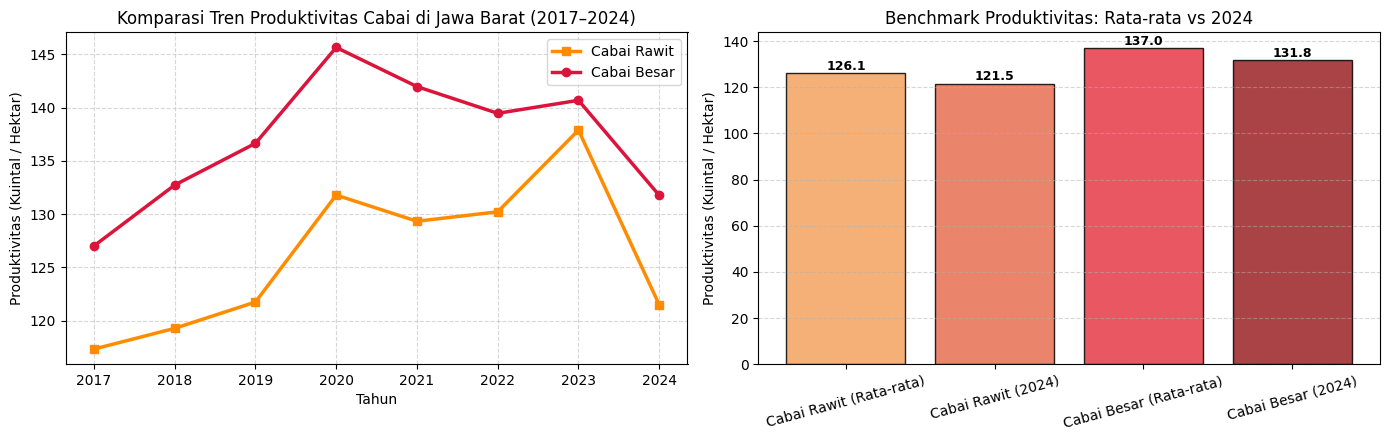

Gambar PNG berhasil disimpan ke: C:\CODING\research_taniAdapt\reports\dataset_audit\figures\ds06_chili_commodities.png


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel 1: Line Chart Komparasi Tren
ax1.plot(cabai_rawit['tahun'], cabai_rawit['produktivitas_sayur_buah'], marker='s', color='darkorange', label='Cabai Rawit', linewidth=2.5)
ax1.plot(cabai_besar['tahun'], cabai_besar['produktivitas_sayur_buah'], marker='o', color='crimson', label='Cabai Besar', linewidth=2.5)
ax1.set_title("Komparasi Tren Produktivitas Cabai di Jawa Barat (2017–2024)")
ax1.set_xlabel("Tahun")
ax1.set_ylabel("Produktivitas (Kuintal / Hektar)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Panel 2: Bar Chart Rata-rata & Nilai Terakhir (2024)
categories = ['Cabai Rawit (Rata-rata)', 'Cabai Rawit (2024)', 'Cabai Besar (Rata-rata)', 'Cabai Besar (2024)']
values = [
    cabai_rawit['produktivitas_sayur_buah'].mean(),
    cabai_rawit[cabai_rawit['tahun'] == 2024]['produktivitas_sayur_buah'].iloc[0],
    cabai_besar['produktivitas_sayur_buah'].mean(),
    cabai_besar[cabai_besar['tahun'] == 2024]['produktivitas_sayur_buah'].iloc[0]
]
colors = ['#f4a261', '#e76f51', '#e63946', '#9b2226']
ax2.bar(categories, values, color=colors, edgecolor='black', alpha=0.85)
ax2.set_title("Benchmark Produktivitas: Rata-rata vs 2024")
ax2.set_ylabel("Produktivitas (Kuintal / Hektar)")
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(values):
    ax2.text(i, v + 1.5, f"{v:.1f}", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
png_out = FIGURES_DIR / "ds06_chili_commodities.png"
plt.savefig(png_out, dpi=150)
plt.show()
print(f"Gambar PNG berhasil disimpan ke: {png_out}")


## Executive Audit Scorecard


In [5]:
scorecard = pd.DataFrame([
    {"Dimensi Audit": "Dataset Identifier", "Hasil & Evaluasi": "DS06 — West Java SBS Horticulture (Chili) Productivity"},
    {"Dimensi Audit": "Penerbit & Sumber", "Hasil & Evaluasi": "Distanhor Jabar / Galura Open Data Jabar"},
    {"Dimensi Audit": "Fokus Komoditas", "Hasil & Evaluasi": "Cabai Besar dan Cabai Rawit (Sayuran Buah Semusim)"},
    {"Dimensi Audit": "Rentang Periode", "Hasil & Evaluasi": "2017 s.d. 2024 (8 Tahun Observasi)"},
    {"Dimensi Audit": "Kelengkapan Nilai", "Hasil & Evaluasi": "PASSED (0 missing value pada komoditas cabai)"},
    {"Dimensi Audit": "Satuan Resmi", "Hasil & Evaluasi": "Kuintal / Hektar"},
    {"Dimensi Audit": "Peran di TaniAdapt", "Hasil & Evaluasi": "Regional Horticulture Outcome Target"},
    {"Dimensi Audit": "Status Disposisi", "Hasil & Evaluasi": "PASS (Target hasil panen hortikultura cabai valid)"},
    {"Dimensi Audit": "Batasan Kritis", "Hasil & Evaluasi": "TIDAK BISA untuk model deteksi penyakit (disease label absen). Rekomendasi: gunakan rule-based weather threshold."}
])

display(scorecard)


,Dimensi Audit,Hasil & Evaluasi
0,Dataset Identifier,DS06 — West Java SBS Horticulture (Chili) Prod...
1,Penerbit & Sumber,Distanhor Jabar / Galura Open Data Jabar
2,Fokus Komoditas,Cabai Besar dan Cabai Rawit (Sayuran Buah Semu...
3,Rentang Periode,2017 s.d. 2024 (8 Tahun Observasi)
4,Kelengkapan Nilai,PASSED (0 missing value pada komoditas cabai)
5,Satuan Resmi,Kuintal / Hektar
6,Peran di TaniAdapt,Regional Horticulture Outcome Target
7,Status Disposisi,PASS (Target hasil panen hortikultura cabai va...
8,Batasan Kritis,TIDAK BISA untuk model deteksi penyakit (disea...
